# Estudi estadístic comparatiu dels models GPT-5.1 i GPT-5.4

Aquest notebook implementa un estudi estadístic aplicat per comparar els models **gpt-5.1** i **gpt-5.4** a partir del dataset d'imatges amb soroll.

L'anàlisi segueix l'índex oficial indicat i utilitza només tècniques bàsiques del temari: estadística descriptiva, gràfics, contrast t aparellat i models lineals amb `lm()`.


## Configuració inicial


In [1]:
# Instal·lació segura i càrrega de paquets.
# Només s'utilitzen les llibreries permeses a l'enunciat.
paquets <- c("tidyverse", "ggplot2", "dplyr", "tidyr", "broom", "knitr", "patchwork")
paquets_falten <- paquets[!vapply(paquets, requireNamespace, logical(1), quietly = TRUE)]

if (length(paquets_falten) > 0) {
  install.packages(paquets_falten, repos = "https://cloud.r-project.org")
}

invisible(lapply(paquets, library, character.only = TRUE))

options(
  dplyr.summarise.inform = FALSE,
  scipen = 999
)

theme_set(theme_minimal(base_size = 12))


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
# El notebook ha de treballar des de l'arrel del projecte.
# Si s'executa des de la carpeta analisis/, pugem un nivell.
if (basename(getwd()) == "analisis") {
  setwd("..")
}

# Ruta del CSV amb tots els models.
ruta_csv <- file.path(
  getwd(),
  "recollida-dades", "experiments", "soroll", "results",
  "sample_colors_tots_models_actual.csv"
)

# Models que es comparen en aquest estudi.
model_a <- "gpt-5.1"
model_b <- "gpt-5.4"

# Lectura de dades.
dades_originals <- readr::read_csv(ruta_csv, show_col_types = FALSE)

# Comprovaci? de columnes necess?ries abans de continuar.
columnes_esperades <- c("image_name", "hex", "chroma", "model", "status", "response_hex", "error_cromatic")
columnes_absents <- setdiff(columnes_esperades, names(dades_originals))

if (length(columnes_absents) > 0) {
  stop(
    paste0(
      "Falten columnes necess?ries al CSV.\n",
      "Columnes esperades: ", paste(columnes_esperades, collapse = ", "), "\n",
      "Columnes trobades: ", paste(names(dades_originals), collapse = ", "), "\n",
      "Columnes absents: ", paste(columnes_absents, collapse = ", ")
    )
  )
}

# Primer filtratge de l'an?lisi: nom?s gpt-5.1 i gpt-5.4 amb resposta correcta.
dades_models <- dades_originals %>%
  filter(model %in% c(model_a, model_b), status == "ok") %>%
  mutate(
    model = factor(model, levels = c(model_a, model_b)),
    error_cromatic = as.numeric(error_cromatic),
    chroma = as.numeric(chroma)
  )

resum_lectura_filtratge <- tibble(
  element = c("Ruta utilitzada", "Files del CSV complet", "Files despr?s del filtratge", "Models de l'an?lisi"),
  valor = c(ruta_csv, nrow(dades_originals), nrow(dades_models), paste(model_a, "i", model_b))
)

knitr::kable(resum_lectura_filtratge, caption = "Lectura i filtratge inicial de les dades")



Table: Lectura i filtratge inicial de les dades

|element                     |valor                                                                                                                                    |
|:---------------------------|:----------------------------------------------------------------------------------------------------------------------------------------|
|Ruta utilitzada             |C:/Users/AdriàSebastià/Documents/dev/color-llm-benchmark/recollida-dades/experiments/soroll/results/sample_colors_tots_models_actual.csv |
|Files del CSV complet       |7000                                                                                                                                     |
|Files despr?s del filtratge |2000                                                                                                                                     |
|Models de l'an?lisi         |gpt-5.1 i gpt-5.4                                                         

## 1. Resum

L'objectiu d'aquest estudi és comparar l'error cromàtic dels models **gpt-5.1** i **gpt-5.4** en una mostra d'imatges amb soroll. La variable resposta és l'`error_cromatic`, la variable explicativa principal és el `model` i la covariable quantitativa és el `chroma`.

Com que els dos models s'avaluen sobre els mateixos estímuls, la comparació principal es fa amb dades aparellades. La diferència aparellada es defineix com:

$$D = Y_{5.1} - Y_{5.4}$$

S'apliquen estadística descriptiva, anàlisi gràfica, validació visual de premisses, contrast t aparellat i models lineals. Les conclusions finals es calculen directament a partir del CSV, sense introduir informació externa.


### Variables de l'estudi

- **Variable resposta \(Y\):** error cromàtic (`error_cromatic`).
- **Variable explicativa \(X\):** model (`gpt-5.1` vs `gpt-5.4`).
- **Covariable \(Z\):** chroma (`chroma`).
- **Unitat experimental:** estímul o imatge (`image_name`).
- **Significat de cada fila:** resposta d'un model concret per a una imatge concreta.

Els dos models s'avaluen sobre els mateixos estímuls; per tant, l'anàlisi principal és aparellada.


## 2. Introducció

### 2.1. Motivació de l'estudi

Comparar models és rellevant perquè permet valorar quin sistema produeix estimacions de color més properes al color objectiu en les mateixes condicions experimentals. En aquest estudi, l'error cromàtic és la variable principal perquè resumeix la distància entre el color real i el color retornat pel model.

El `chroma` pot influir en la dificultat de predicció perquè representa el grau de saturació del color. En colors amb chroma alt, petites desviacions en algun canal RGB poden produir errors més grans.

### 2.2. Objectius

- Comparar l'error cromàtic entre **gpt-5.1** i **gpt-5.4**.
- Estudiar si hi ha diferències en les mitjanes.
- Comparar la variabilitat de l'error.
- Estudiar la relació entre `chroma` i error.
- Ajustar models lineals senzills.
- Validar visualment les premisses.
- Valorar si una transformació logarítmica és adequada.
- Estudiar la comparabilitat de la mostra.


## 3. Metodologia

### 3.1. Disseny de l'estudi

L'estudi és comparatiu i aparellat: cada imatge s'avalua amb els dos models. Per això la unitat experimental és l'**estímul o imatge** (`image_name`), i cada fila del dataset representa la resposta d'un model concret per a una imatge concreta.

La diferència aparellada és:

$$D_i = Y_{i,5.1} - Y_{i,5.4}$$

Aquest disseny justifica el contrast t aparellat, perquè la comparació es fa dins de cada imatge i no entre dues mostres independents. Abans d'interpretar el contrast cal revisar les premisses amb gràfics, especialment la distribució de les diferències.


### 3.2. Descripció de les dades


In [3]:
# Descripci? del CSV complet ja carregat a la cel?la inicial.
resum_inicial <- tibble(
  indicador = c(
    "Nombre total d'observacions al CSV",
    "Nombre de variables",
    "Nombre d'imatges",
    "Nombre de models",
    "Observacions dels dos models analitzats"
  ),
  valor = c(
    nrow(dades_originals),
    ncol(dades_originals),
    n_distinct(dades_originals$image_name),
    n_distinct(dades_originals$model),
    nrow(dades_models)
  )
)

knitr::kable(resum_inicial, caption = "Resum inicial del dataset")



Table: Resum inicial del dataset

|indicador                               | valor|
|:---------------------------------------|-----:|
|Nombre total d'observacions al CSV      |  7000|
|Nombre de variables                     |     7|
|Nombre d'imatges                        |  1000|
|Nombre de models                        |     7|
|Observacions dels dos models analitzats |  2000|

In [4]:
# Variables disponibles i models presents al CSV.
variables_disponibles <- tibble(variable = names(dades_originals))
models_presents <- dades_originals %>%
  count(model, name = "observacions") %>%
  arrange(model)

knitr::kable(variables_disponibles, caption = "Variables disponibles al CSV")
knitr::kable(models_presents, caption = "Models presents al CSV")




Table: Variables disponibles al CSV

|variable       |
|:--------------|
|image_name     |
|hex            |
|chroma         |
|model          |
|status         |
|response_hex   |
|error_cromatic |



Table: Models presents al CSV

|model       | observacions|
|:-----------|------------:|
|gpt-4o      |         1000|
|gpt-4o-mini |         1000|
|gpt-5       |         1000|
|gpt-5.1     |         1000|
|gpt-5.2     |         1000|
|gpt-5.4     |         1000|
|gpt-5.5     |         1000|

In [5]:
# Resum de valors perduts, duplicats i rangs abans de filtrar.
resum_qualitat_global <- tibble(
  indicador = c(
    "Valors perduts a image_name",
    "Valors perduts a model",
    "Valors perduts a error_cromatic",
    "Valors perduts a chroma",
    "Files duplicades completes",
    "Mínim error_cromatic",
    "Màxim error_cromatic",
    "Mínim chroma",
    "Màxim chroma"
  ),
  valor = c(
    sum(is.na(dades_originals$image_name)),
    sum(is.na(dades_originals$model)),
    sum(is.na(dades_originals$error_cromatic)),
    sum(is.na(dades_originals$chroma)),
    sum(duplicated(dades_originals)),
    min(dades_originals$error_cromatic, na.rm = TRUE),
    max(dades_originals$error_cromatic, na.rm = TRUE),
    min(dades_originals$chroma, na.rm = TRUE),
    max(dades_originals$chroma, na.rm = TRUE)
  )
)

knitr::kable(resum_qualitat_global, digits = 4, caption = "Control inicial de qualitat del dataset complet")




Table: Control inicial de qualitat del dataset complet

|indicador                       |    valor|
|:-------------------------------|--------:|
|Valors perduts a image_name     |   0.0000|
|Valors perduts a model          |   0.0000|
|Valors perduts a error_cromatic |   0.0000|
|Valors perduts a chroma         |   0.0000|
|Files duplicades completes      |   0.0000|
|Mínim error_cromatic            |   0.0000|
|Màxim error_cromatic            | 232.5812|
|Mínim chroma                    |   0.0165|
|Màxim chroma                    |   0.9363|

In [6]:
# Resum del filtratge inicial dels dos models de l'estudi.
resum_filtrat <- dades_models %>%
  count(model, name = "observacions")

knitr::kable(resum_filtrat, caption = "Observacions filtrades per model")



Table: Observacions filtrades per model

|model   | observacions|
|:-------|------------:|
|gpt-5.1 |         1000|
|gpt-5.4 |         1000|

In [7]:
# Comprovació de l'aparellament.
duplicats_per_model <- dades_models %>%
  count(image_name, model, name = "n") %>%
  filter(n != 1)

parelles_comprovacio <- dades_models %>%
  distinct(image_name, model) %>%
  count(image_name, name = "models_per_imatge")

parelles_valides <- parelles_comprovacio %>%
  filter(models_per_imatge == 2)

parelles_incompletes <- parelles_comprovacio %>%
  filter(models_per_imatge != 2)

if (nrow(duplicats_per_model) > 0) {
  warning("S'han detectat imatges amb més d'una observació per al mateix model.")
}

resum_aparellament <- tibble(
  indicador = c(
    "Imatges amb parella vàlida",
    "Imatges incompletes",
    "Duplicats image_name-model"
  ),
  valor = c(
    nrow(parelles_valides),
    nrow(parelles_incompletes),
    nrow(duplicats_per_model)
  )
)

knitr::kable(resum_aparellament, caption = "Comprovació de parelles vàlides")




Table: Comprovació de parelles vàlides

|indicador                  | valor|
|:--------------------------|-----:|
|Imatges amb parella vàlida |  1000|
|Imatges incompletes        |     0|
|Duplicats image_name-model |     0|

In [8]:
# Creació de la taula aparellada.
dades_aparellades <- dades_models %>%
  select(image_name, hex, chroma, model, error_cromatic, response_hex) %>%
  pivot_wider(
    names_from = model,
    values_from = c(error_cromatic, response_hex),
    names_sep = "__"
  ) %>%
  filter(
    !is.na(.data[[paste0("error_cromatic__", model_a)]]),
    !is.na(.data[[paste0("error_cromatic__", model_b)]])
  ) %>%
  transmute(
    image_name,
    hex,
    chroma,
    error_5_1 = .data[[paste0("error_cromatic__", model_a)]],
    error_5_4 = .data[[paste0("error_cromatic__", model_b)]],
    resposta_5_1 = .data[[paste0("response_hex__", model_a)]],
    resposta_5_4 = .data[[paste0("response_hex__", model_b)]],
    D = error_5_1 - error_5_4,
    mitjana_parella = (error_5_1 + error_5_4) / 2
  )

knitr::kable(head(dades_aparellades, 10), digits = 4, caption = "Primeres files de la taula aparellada")




Table: Primeres files de la taula aparellada

|image_name |hex    | chroma| error_5_1| error_5_4|resposta_5_1 |resposta_5_4 |         D| mitjana_parella|
|:----------|:------|------:|---------:|---------:|:------------|:------------|---------:|---------------:|
|00C859.png |00C859 | 0.5870|   46.4866|   50.9706|2ECE56       |23ED5B       |   -4.4840|         48.7286|
|00C895.png |00C895 | 0.4160|   25.1595|   57.0088|0AC1AB       |1BECB8       |  -31.8493|         41.0841|
|00EEAA.png |00EEAA | 0.4950|   21.5407|   33.9116|00E6BE       |0EFDC5       |  -12.3710|         27.7262|
|00F4D0.png |00F4D0 | 0.4222|    6.4031|   52.5833|00EFD4       |24FEF5       |  -46.1801|         29.4932|
|010E7C.png |010E7C | 0.5415|   16.4012|  131.7498|0E1682       |0000FF       | -115.3485|         74.0755|
|014F70.png |014F70 | 0.1937|   25.8070|   16.6733|0C6080       |005D79       |    9.1336|         21.2402|
|015940.png |015940 | 0.2324|   19.3132|   15.1658|0A5F50       |076645       |    4.147

**Interpretació aplicada.** Les dades filtrades permeten una comparació aparellada si cada `image_name` té una observació de **gpt-5.1** i una de **gpt-5.4**. La taula anterior transforma el dataset a format ample per calcular directament la diferència \(D\).


### 3.2.1. Recollida de dades i generació de les imatges


In [9]:
# Revisió de variables relacionades amb la recollida o les condicions de generació.
variables_condicions <- c("prompt", "size", "mida", "format", "compression", "compressio", "width", "height")
variables_condicions_trobades <- intersect(variables_condicions, names(dades_originals))

if (length(variables_condicions_trobades) == 0) {
  condicions_resum <- tibble(
    variable = variables_condicions,
    estat = "PENDENT",
    comentari = "Aquesta variable no apareix al CSV d'entrada."
  )
  knitr::kable(condicions_resum, caption = "Informació disponible sobre condicions de generació")
} else {
  condicions_resum <- dades_originals %>%
    select(all_of(c("model", variables_condicions_trobades))) %>%
    pivot_longer(-model, names_to = "variable", values_to = "valor") %>%
    count(model, variable, valor, name = "n") %>%
    arrange(variable, model, desc(n))
  knitr::kable(condicions_resum, caption = "Resum de condicions de generació trobades")
}




Table: Informació disponible sobre condicions de generació

|variable    |estat   |comentari                                     |
|:-----------|:-------|:---------------------------------------------|
|prompt      |PENDENT |Aquesta variable no apareix al CSV d'entrada. |
|size        |PENDENT |Aquesta variable no apareix al CSV d'entrada. |
|mida        |PENDENT |Aquesta variable no apareix al CSV d'entrada. |
|format      |PENDENT |Aquesta variable no apareix al CSV d'entrada. |
|compression |PENDENT |Aquesta variable no apareix al CSV d'entrada. |
|compressio  |PENDENT |Aquesta variable no apareix al CSV d'entrada. |
|width       |PENDENT |Aquesta variable no apareix al CSV d'entrada. |
|height      |PENDENT |Aquesta variable no apareix al CSV d'entrada. |

**Interpretació aplicada.** El CSV utilitzat conté les variables necessàries per comparar errors, models, colors i chroma. La informació específica de `prompt`, mida, format o compressió no està disponible al fitxer; per tant, aquesta part queda marcada com a **PENDENT**. La comparació és coherent perquè els dos models s'avaluen sobre les mateixes imatges, però no es pot comprovar des d'aquest CSV si totes les condicions de generació van ser idèntiques.


### 3.2.2. Càlcul de l'error cromàtic

En aquest estudi l'error cromàtic representa la distància entre el color objectiu i el color retornat pel model. El CSV ja inclou la variable `error_cromatic`, que s'utilitza com a variable resposta.

Si hi hagués coordenades Lab, l'error es calcularia com:

$$error = \sqrt{(L_1-L_2)^2 + (a_1-a_2)^2 + (b_1-b_2)^2}$$


In [10]:
# Comprovació de si existeixen coordenades Lab i descripció de l'error disponible.
columnes_lab <- c("L1", "a1", "b1", "L2", "a2", "b2")
hi_ha_lab <- all(columnes_lab %in% names(dades_originals))

if (hi_ha_lab) {
  missatge_error <- "El CSV conté coordenades Lab; es podria calcular l'error Lab."
} else {
  missatge_error <- "El CSV no conté coordenades Lab completes; s'utilitza error_cromatic ja calculat."
}

resum_error_global <- dades_models %>%
  summarise(
    n = n(),
    minim = min(error_cromatic, na.rm = TRUE),
    q1 = quantile(error_cromatic, 0.25, na.rm = TRUE),
    mediana = median(error_cromatic, na.rm = TRUE),
    mitjana = mean(error_cromatic, na.rm = TRUE),
    q3 = quantile(error_cromatic, 0.75, na.rm = TRUE),
    maxim = max(error_cromatic, na.rm = TRUE),
    sd = sd(error_cromatic, na.rm = TRUE)
  )

missatge_error
knitr::kable(resum_error_global, digits = 4, caption = "Distribució global de l'error cromàtic dels dos models")


[1] "El CSV no conté coordenades Lab completes; s'utilitza error_cromatic ja calculat."



Table: Distribució global de l'error cromàtic dels dos models

|    n| minim|      q1| mediana| mitjana|      q3|    maxim|      sd|
|----:|-----:|-------:|-------:|-------:|-------:|--------:|-------:|
| 2000|     1| 20.9583| 32.9242| 37.2881| 48.3218| 232.5812| 22.7425|

### 3.2.3. Càlcul del chroma

El `chroma` representa la saturació o intensitat cromàtica del color objectiu. El CSV ja inclou aquesta variable i s'utilitza com a covariable \(Z\).

Si hi hagués coordenades Lab del color objectiu, el chroma es podria calcular com:

$$C = \sqrt{a^2 + b^2}$$


In [11]:
# Descripció del chroma disponible al CSV.
resum_chroma <- dades_models %>%
  summarise(
    n = n(),
    minim = min(chroma, na.rm = TRUE),
    q1 = quantile(chroma, 0.25, na.rm = TRUE),
    mediana = median(chroma, na.rm = TRUE),
    mitjana = mean(chroma, na.rm = TRUE),
    q3 = quantile(chroma, 0.75, na.rm = TRUE),
    maxim = max(chroma, na.rm = TRUE),
    sd = sd(chroma, na.rm = TRUE)
  )

knitr::kable(resum_chroma, digits = 4, caption = "Distribució del chroma en les observacions filtrades")




Table: Distribució del chroma en les observacions filtrades

|    n|  minim|     q1| mediana| mitjana|     q3|  maxim|     sd|
|----:|------:|------:|-------:|-------:|------:|------:|------:|
| 2000| 0.0165| 0.2708|   0.419|  0.4321| 0.5904| 0.9363| 0.2055|

### 3.3. Procediment

El pipeline aplicat és:

1. lectura de dades;
2. neteja i comprovació de columnes;
3. filtratge dels models **gpt-5.1** i **gpt-5.4**;
4. comprovació de l'aparellament per `image_name`;
5. estadística descriptiva;
6. anàlisi bivariant entre `chroma` i error;
7. validació visual de premisses;
8. contrast t aparellat;
9. models lineals;
10. interpretació aplicada dels resultats.


### 3.3.1. Control de qualitat i comparabilitat de la mostra


In [12]:
# Control de qualitat específic dels dos models.
qualitat_models <- dades_models %>%
  group_by(model) %>%
  summarise(
    observacions = n(),
    imatges_uniques = n_distinct(image_name),
    colors_objectiu_unics = n_distinct(hex),
    respostes_uniques = n_distinct(response_hex),
    valors_perduts_error = sum(is.na(error_cromatic)),
    valors_perduts_chroma = sum(is.na(chroma)),
    duplicats_image_model = sum(duplicated(paste(image_name, model))),
    minim_error = min(error_cromatic, na.rm = TRUE),
    maxim_error = max(error_cromatic, na.rm = TRUE),
    minim_chroma = min(chroma, na.rm = TRUE),
    maxim_chroma = max(chroma, na.rm = TRUE),
    .groups = "drop"
  )

knitr::kable(qualitat_models, digits = 4, caption = "Control de qualitat i comparabilitat per model")




Table: Control de qualitat i comparabilitat per model

|model   | observacions| imatges_uniques| colors_objectiu_unics| respostes_uniques| valors_perduts_error| valors_perduts_chroma| duplicats_image_model| minim_error| maxim_error| minim_chroma| maxim_chroma|
|:-------|------------:|---------------:|---------------------:|-----------------:|--------------------:|---------------------:|---------------------:|-----------:|-----------:|------------:|------------:|
|gpt-5.1 |         1000|            1000|                  1000|               984|                    0|                     0|                     0|      1.0000|    111.2025|       0.0165|       0.9363|
|gpt-5.4 |         1000|            1000|                  1000|               976|                    0|                     0|                     0|      2.2361|    232.5812|       0.0165|       0.9363|



Table: Resum del chroma per model

|model   | mitjana_chroma| mediana_chroma| sd_chroma|
|:-------|--------------:|--------------:|---------:|
|gpt-5.1 |         0.4321|          0.419|    0.2055|
|gpt-5.4 |         0.4321|          0.419|    0.2055|

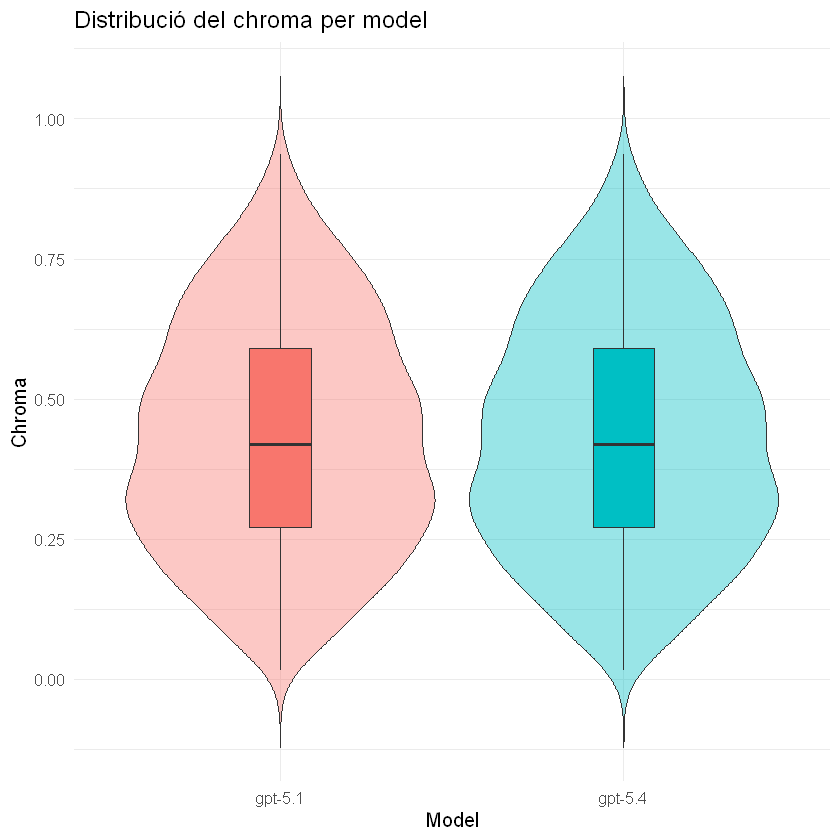

In [13]:
# Comparació del chroma per model. Si la mostra és aparellada, hauria de ser pràcticament idèntic.
chroma_per_model <- dades_models %>%
  group_by(model) %>%
  summarise(
    mitjana_chroma = mean(chroma, na.rm = TRUE),
    mediana_chroma = median(chroma, na.rm = TRUE),
    sd_chroma = sd(chroma, na.rm = TRUE),
    .groups = "drop"
  )

ggplot(dades_models, aes(x = model, y = chroma, fill = model)) +
  geom_violin(alpha = 0.4, trim = FALSE) +
  geom_boxplot(width = 0.18, outlier.alpha = 0.25) +
  labs(
    title = "Distribució del chroma per model",
    x = "Model",
    y = "Chroma"
  ) +
  guides(fill = "none")

knitr::kable(chroma_per_model, digits = 4, caption = "Resum del chroma per model")


**Interpretació aplicada.** Com que els models s'apliquen sobre les mateixes imatges, la distribució del `chroma` hauria de ser equivalent entre models. Les diferències en l'error no s'haurien d'atribuir a una mostra de colors diferent, sinó al comportament dels models o a altres factors no registrats al CSV.


## 3.4. Anàlisi estadístic

### 3.4.1. Estadística descriptiva


In [14]:
# Estadística descriptiva de l'error per model.
descriptiva_error <- dades_models %>%
  group_by(model) %>%
  summarise(
    n = n(),
    mitjana = mean(error_cromatic, na.rm = TRUE),
    mediana = median(error_cromatic, na.rm = TRUE),
    desviacio_tipica = sd(error_cromatic, na.rm = TRUE),
    variancia = var(error_cromatic, na.rm = TRUE),
    minim = min(error_cromatic, na.rm = TRUE),
    q1 = quantile(error_cromatic, 0.25, na.rm = TRUE),
    q3 = quantile(error_cromatic, 0.75, na.rm = TRUE),
    iqr = IQR(error_cromatic, na.rm = TRUE),
    maxim = max(error_cromatic, na.rm = TRUE),
    .groups = "drop"
  )

knitr::kable(descriptiva_error, digits = 4, caption = "Estadística descriptiva de l'error cromàtic per model")




Table: Estadística descriptiva de l'error cromàtic per model

|model   |    n| mitjana| mediana| desviacio_tipica| variancia|  minim|      q1|      q3|     iqr|    maxim|
|:-------|----:|-------:|-------:|----------------:|---------:|------:|-------:|-------:|-------:|--------:|
|gpt-5.1 | 1000| 26.9591| 24.8395|          13.9302|  194.0509| 1.0000| 16.5756| 35.5281| 18.9526| 111.2025|
|gpt-5.4 | 1000| 47.6172| 43.7664|          25.0463|  627.3188| 2.2361| 30.5614| 60.2785| 29.7171| 232.5812|

**Interpretació aplicada.** Aquesta taula permet comparar el nivell mitjà d'error i la dispersió de cada model. Una mitjana menor indica millor precisió cromàtica; una desviació típica menor indica més estabilitat.


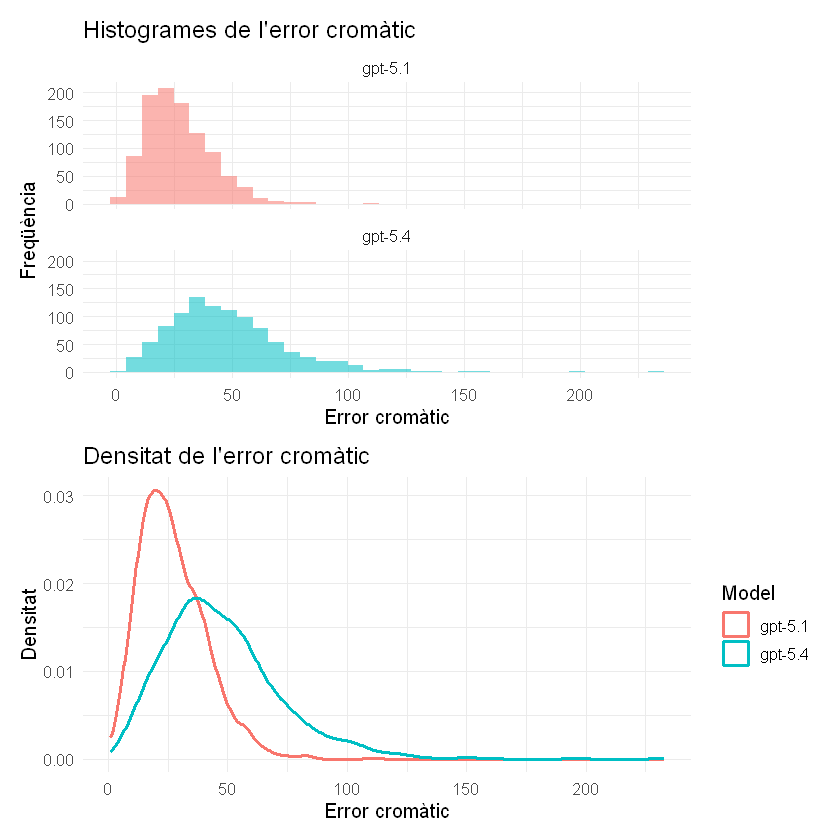

In [15]:
# Histogrames i densitats de l'error.
graf_hist <- ggplot(dades_models, aes(x = error_cromatic, fill = model)) +
  geom_histogram(alpha = 0.55, bins = 35, position = "identity") +
  facet_wrap(~ model, ncol = 1) +
  labs(
    title = "Histogrames de l'error cromàtic",
    x = "Error cromàtic",
    y = "Freqüència"
  ) +
  guides(fill = "none")

graf_densitat <- ggplot(dades_models, aes(x = error_cromatic, color = model)) +
  geom_density(linewidth = 1) +
  labs(
    title = "Densitat de l'error cromàtic",
    x = "Error cromàtic",
    y = "Densitat",
    color = "Model"
  )

graf_hist / graf_densitat


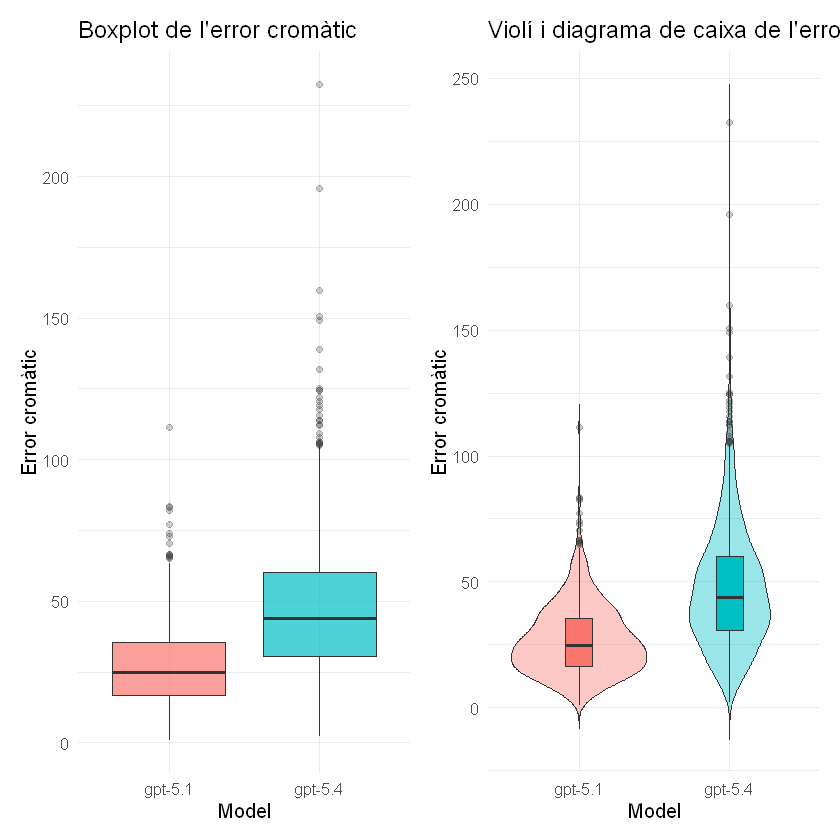

In [16]:
# Boxplots i violí + boxplot.
graf_boxplot <- ggplot(dades_models, aes(x = model, y = error_cromatic, fill = model)) +
  geom_boxplot(alpha = 0.7, outlier.alpha = 0.25) +
  labs(
    title = "Boxplot de l'error cromàtic",
    x = "Model",
    y = "Error cromàtic"
  ) +
  guides(fill = "none")

graf_violi <- ggplot(dades_models, aes(x = model, y = error_cromatic, fill = model)) +
  geom_violin(alpha = 0.4, trim = FALSE) +
  geom_boxplot(width = 0.18, outlier.alpha = 0.25) +
  labs(
    title = "Violí i diagrama de caixa de l'error cromàtic",
    x = "Model",
    y = "Error cromàtic"
  ) +
  guides(fill = "none")

graf_boxplot + graf_violi


In [17]:
# Concentració de respostes i repeticions.
concentracio_respostes <- dades_models %>%
  group_by(model) %>%
  summarise(
    n = n(),
    valors_error_unics = n_distinct(error_cromatic),
    ratio_error_unic = valors_error_unics / n,
    respostes_hex_uniques = n_distinct(response_hex),
    ratio_hex_unic = respostes_hex_uniques / n,
    repeticio_maxima_hex = max(table(response_hex)),
    percentatge_respostes_repetides = 100 * (1 - ratio_hex_unic),
    .groups = "drop"
  )

knitr::kable(concentracio_respostes, digits = 4, caption = "Concentració de respostes per model")




Table: Concentració de respostes per model

|model   |    n| valors_error_unics| ratio_error_unic| respostes_hex_uniques| ratio_hex_unic| repeticio_maxima_hex| percentatge_respostes_repetides|
|:-------|----:|------------------:|----------------:|---------------------:|--------------:|--------------------:|-------------------------------:|
|gpt-5.1 | 1000|                718|            0.718|                   984|          0.984|                    4|                             1.6|
|gpt-5.4 | 1000|                891|            0.891|                   976|          0.976|                   12|                             2.4|

**Interpretació aplicada.** La concentració de respostes permet detectar si un model tendeix a reutilitzar els mateixos colors. Una ràtio baixa de respostes HEX úniques indica més repetició i pot explicar part de l'error.


In [18]:
# Percentatge d'encert segons llindars d'error.
llindars <- c(10, 20, 30, 50)

percentatge_encert <- dades_models %>%
  group_by(model) %>%
  summarise(
    n = n(),
    exact_hex_pct = 100 * mean(response_hex == hex, na.rm = TRUE),
    err_le_10_pct = 100 * mean(error_cromatic <= 10, na.rm = TRUE),
    err_le_20_pct = 100 * mean(error_cromatic <= 20, na.rm = TRUE),
    err_le_30_pct = 100 * mean(error_cromatic <= 30, na.rm = TRUE),
    err_le_50_pct = 100 * mean(error_cromatic <= 50, na.rm = TRUE),
    .groups = "drop"
  )

knitr::kable(percentatge_encert, digits = 2, caption = "Percentatge d'encert segons llindars d'error")




Table: Percentatge d'encert segons llindars d'error

|model   |    n| exact_hex_pct| err_le_10_pct| err_le_20_pct| err_le_30_pct| err_le_50_pct|
|:-------|----:|-------------:|-------------:|-------------:|-------------:|-------------:|
|gpt-5.1 | 1000|             0|           7.7|          35.8|          64.3|          93.7|
|gpt-5.4 | 1000|             0|           2.0|          10.5|          24.1|          59.8|

**Interpretació aplicada.** Els llindars mostren la proporció de prediccions amb error petit o moderat. Aquesta lectura complementa la mitjana, perquè mostra si un model concentra més observacions prop del color real.


### 3.4.2. Anàlisi bivariant


In [19]:
# Correlació entre chroma i error per model.
correlacio_chroma_error <- dades_models %>%
  group_by(model) %>%
  summarise(
    n = n(),
    correlacio = cor(chroma, error_cromatic, use = "complete.obs"),
    .groups = "drop"
  )

knitr::kable(correlacio_chroma_error, digits = 4, caption = "Correlació entre chroma i error cromàtic")




Table: Correlació entre chroma i error cromàtic

|model   |    n| correlacio|
|:-------|----:|----------:|
|gpt-5.1 | 1000|     0.2439|
|gpt-5.4 | 1000|    -0.0356|

`geom_smooth()` using formula = 'y ~ x'


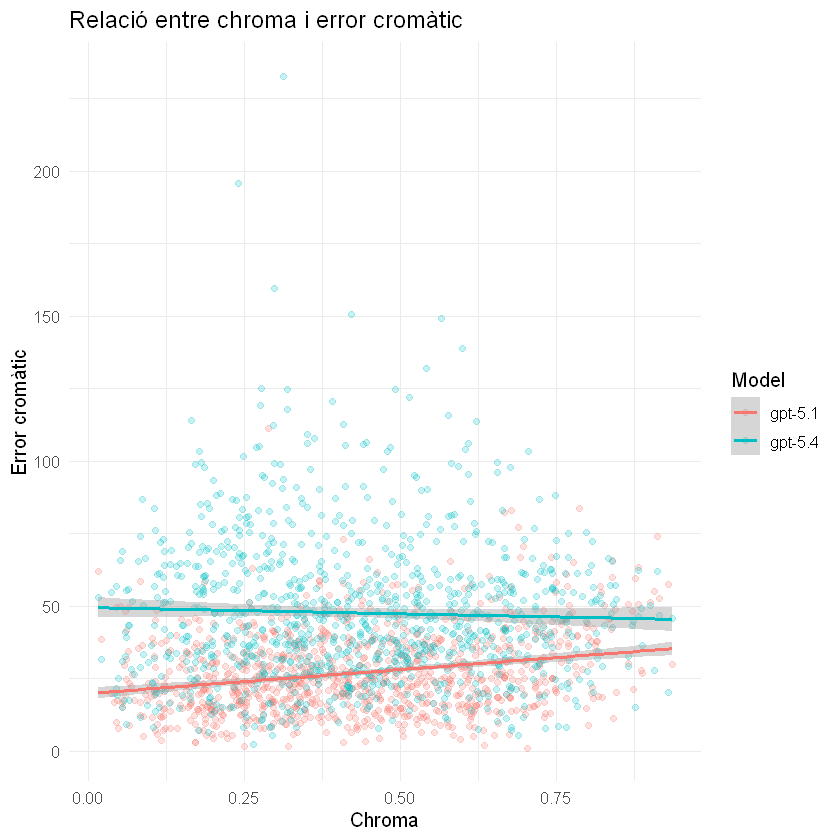

In [20]:
# Gràfic error vs chroma amb regressió visual.
ggplot(dades_models, aes(x = chroma, y = error_cromatic, color = model)) +
  geom_point(alpha = 0.22) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "Relació entre chroma i error cromàtic",
    x = "Chroma",
    y = "Error cromàtic",
    color = "Model"
  )




Table: Error mitjà per bucket de chroma

|model   |bucket_chroma  |   n| error_mitja| error_mediana|
|:-------|:--------------|---:|-----------:|-------------:|
|gpt-5.1 |Q1 chroma baix | 250|     23.1037|       20.6881|
|gpt-5.1 |Q2             | 250|     26.6496|       24.9999|
|gpt-5.1 |Q3             | 250|     26.4027|       24.7378|
|gpt-5.1 |Q4 chroma alt  | 250|     31.6804|       29.1290|
|gpt-5.4 |Q1 chroma baix | 250|     47.9688|       45.7387|
|gpt-5.4 |Q2             | 250|     49.4190|       44.3000|
|gpt-5.4 |Q3             | 250|     47.3163|       42.2255|
|gpt-5.4 |Q4 chroma alt  | 250|     45.7648|       44.5028|

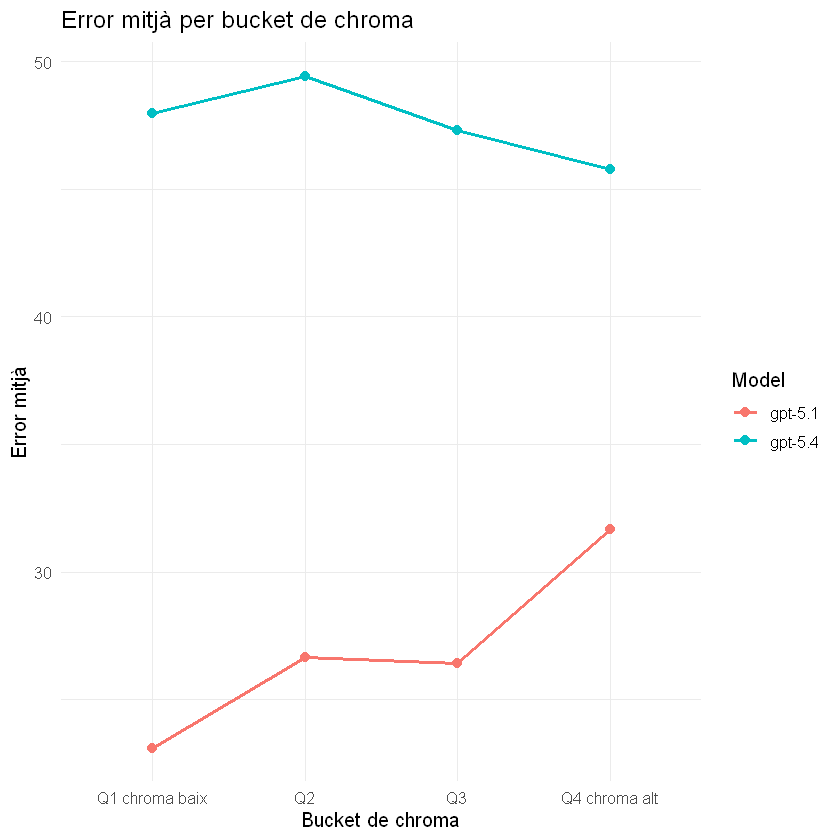

In [21]:
# Creació de 4 buckets de chroma per quartils.
dades_models <- dades_models %>%
  mutate(
    bucket_chroma = ntile(chroma, 4),
    bucket_chroma = factor(
      bucket_chroma,
      levels = 1:4,
      labels = c("Q1 chroma baix", "Q2", "Q3", "Q4 chroma alt")
    )
  )

resum_buckets <- dades_models %>%
  group_by(model, bucket_chroma) %>%
  summarise(
    n = n(),
    error_mitja = mean(error_cromatic, na.rm = TRUE),
    error_mediana = median(error_cromatic, na.rm = TRUE),
    .groups = "drop"
  )

ggplot(resum_buckets, aes(x = bucket_chroma, y = error_mitja, group = model, color = model)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2.5) +
  labs(
    title = "Error mitjà per bucket de chroma",
    x = "Bucket de chroma",
    y = "Error mitjà",
    color = "Model"
  )

knitr::kable(resum_buckets, digits = 4, caption = "Error mitjà per bucket de chroma")


**Interpretació aplicada.** Aquesta anàlisi indica si l'error varia amb la saturació del color. Si l'error mitjà augmenta als buckets de chroma alt, els colors més saturats són més difícils per al model en aquest dataset.


### 3.4.3. Validació de premisses


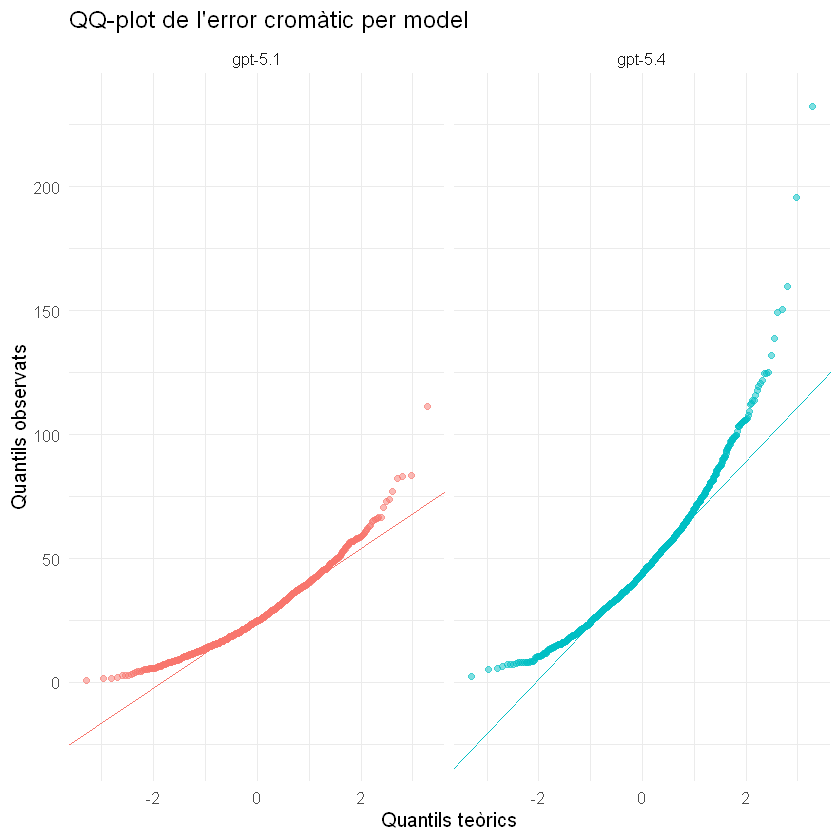

In [22]:
# QQ-plot de l'error per model.
ggplot(dades_models, aes(sample = error_cromatic, color = model)) +
  stat_qq(alpha = 0.5) +
  stat_qq_line() +
  facet_wrap(~ model) +
  labs(
    title = "QQ-plot de l'error cromàtic per model",
    x = "Quantils teòrics",
    y = "Quantils observats",
    color = "Model"
  ) +
  guides(color = "none")


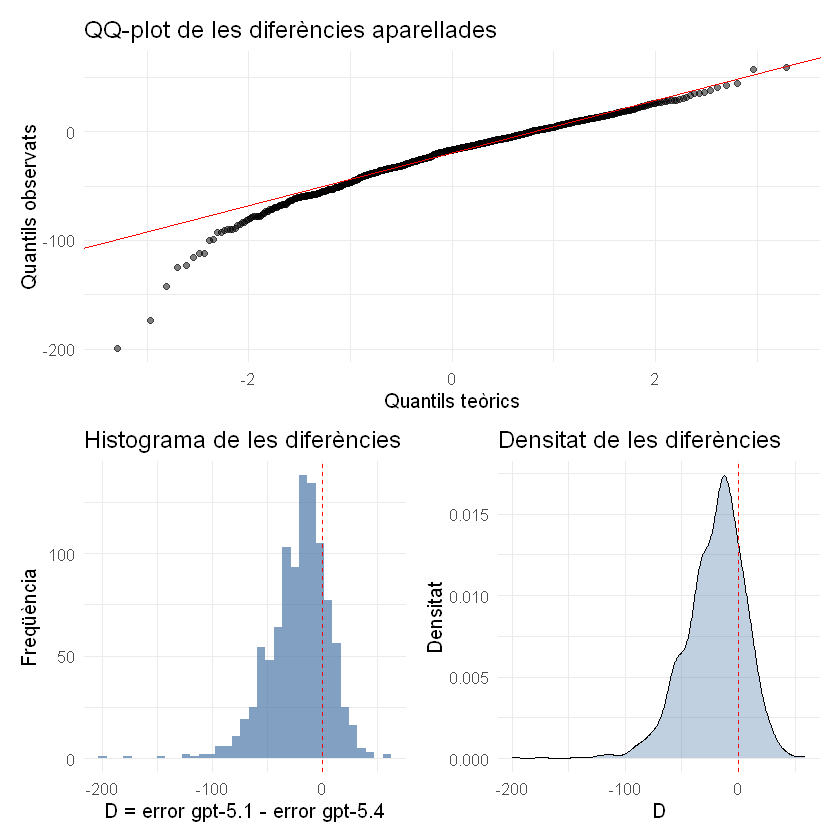

In [23]:
# QQ-plot, histograma i densitat de les diferències aparellades.
graf_qq_D <- ggplot(dades_aparellades, aes(sample = D)) +
  stat_qq(alpha = 0.5) +
  stat_qq_line(color = "red") +
  labs(
    title = "QQ-plot de les diferències aparellades",
    x = "Quantils teòrics",
    y = "Quantils observats"
  )

graf_hist_D <- ggplot(dades_aparellades, aes(x = D)) +
  geom_histogram(bins = 35, fill = "#4C78A8", alpha = 0.7) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "red") +
  labs(
    title = "Histograma de les diferències",
    x = "D = error gpt-5.1 - error gpt-5.4",
    y = "Freqüència"
  )

graf_dens_D <- ggplot(dades_aparellades, aes(x = D)) +
  geom_density(fill = "#4C78A8", alpha = 0.35) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "red") +
  labs(
    title = "Densitat de les diferències",
    x = "D",
    y = "Densitat"
  )

graf_qq_D / (graf_hist_D + graf_dens_D)


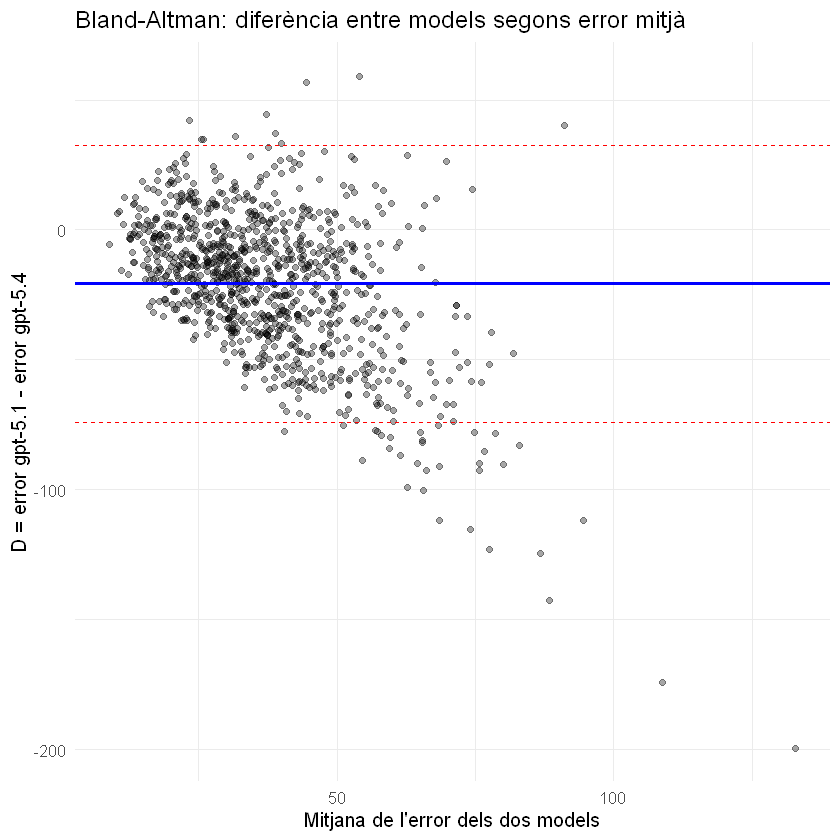

In [24]:
# Bland-Altman plot.
ggplot(dades_aparellades, aes(x = mitjana_parella, y = D)) +
  geom_point(alpha = 0.35) +
  geom_hline(yintercept = mean(dades_aparellades$D), color = "blue", linewidth = 1) +
  geom_hline(
    yintercept = mean(dades_aparellades$D) + 1.96 * sd(dades_aparellades$D),
    linetype = "dashed",
    color = "red"
  ) +
  geom_hline(
    yintercept = mean(dades_aparellades$D) - 1.96 * sd(dades_aparellades$D),
    linetype = "dashed",
    color = "red"
  ) +
  labs(
    title = "Bland-Altman: diferència entre models segons error mitjà",
    x = "Mitjana de l'error dels dos models",
    y = "D = error gpt-5.1 - error gpt-5.4"
  )


**Interpretació aplicada.** Els gràfics anteriors s'utilitzen per revisar si el contrast aparellat és raonable en aquest dataset. El QQ-plot de \(D\) és el més rellevant per al t-test aparellat. El Bland-Altman permet veure si la diferència entre models canvia quan el nivell mitjà d'error és més alt.


### 3.4.4. Contrast d'hipòtesis


In [25]:
# Contrast t aparellat.
test_t_aparellat <- t.test(dades_aparellades$error_5_1, dades_aparellades$error_5_4, paired = TRUE)

resum_test_t <- broom::tidy(test_t_aparellat) %>%
  transmute(
    diferencia_mitjana = estimate,
    conf_low = conf.low,
    conf_high = conf.high,
    estadistic_t = statistic,
    graus_llibertat = parameter,
    p_value = p.value
  )

knitr::kable(resum_test_t, digits = 6, caption = "Resultat del test t aparellat")




Table: Resultat del test t aparellat

| diferencia_mitjana|  conf_low| conf_high| estadistic_t| graus_llibertat| p_value|
|------------------:|---------:|---------:|------------:|---------------:|-------:|
|          -20.65811| -22.34709| -18.96914|    -24.00164|             999|       0|

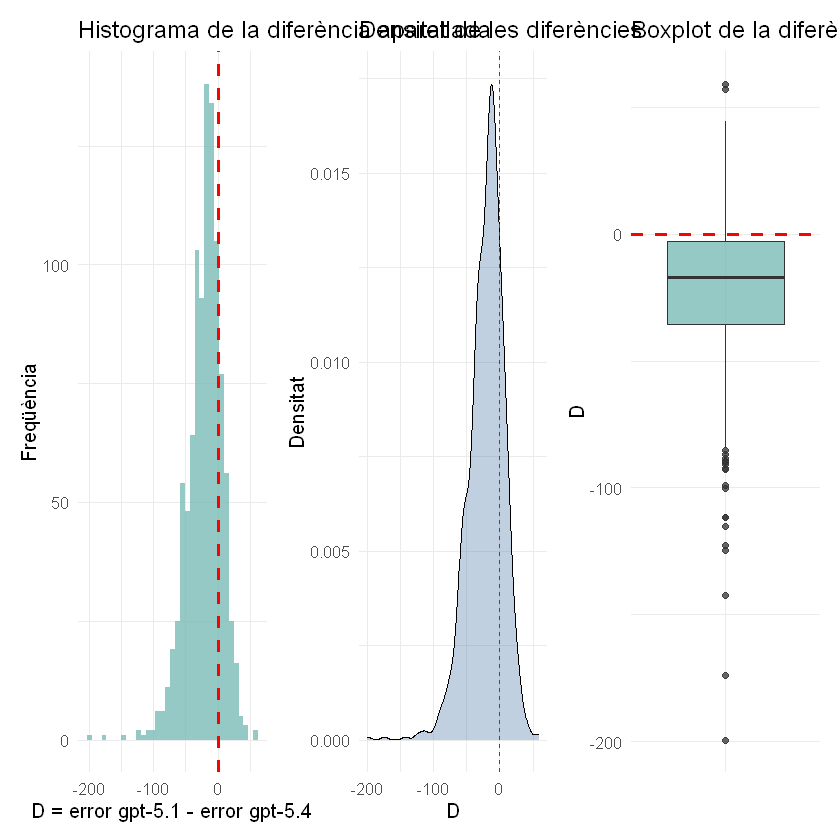

In [26]:
# Gràfics de les diferències amb línia vertical a zero.
graf_diff_hist <- ggplot(dades_aparellades, aes(x = D)) +
  geom_histogram(bins = 35, fill = "#72B7B2", alpha = 0.75) +
  geom_vline(xintercept = 0, color = "red", linetype = "dashed", linewidth = 1) +
  labs(
    title = "Histograma de la diferència aparellada",
    x = "D = error gpt-5.1 - error gpt-5.4",
    y = "Freqüència"
  )

graf_diff_box <- ggplot(dades_aparellades, aes(y = D, x = "")) +
  geom_boxplot(fill = "#72B7B2", alpha = 0.75) +
  geom_hline(yintercept = 0, color = "red", linetype = "dashed", linewidth = 1) +
  labs(
    title = "Boxplot de la diferència aparellada",
    x = "",
    y = "D"
  )

graf_diff_hist + graf_dens_D + graf_diff_box


**Interpretació aplicada.** Si \(D\) és negativa, l'error de **gpt-5.1** és menor que el de **gpt-5.4** en mitjana. Si l'interval de confiança de \(D\) no inclou zero, hi ha evidència estadística de diferència entre models.


### 3.4.5. Comparació de variabilitat




Table: Comparació descriptiva de variabilitat

|model   |    n| desviacio_tipica| variancia|     iqr|     rang|
|:-------|----:|----------------:|---------:|-------:|--------:|
|gpt-5.1 | 1000|          13.9302|  194.0509| 18.9526| 110.2025|
|gpt-5.4 | 1000|          25.0463|  627.3188| 29.7171| 230.3451|

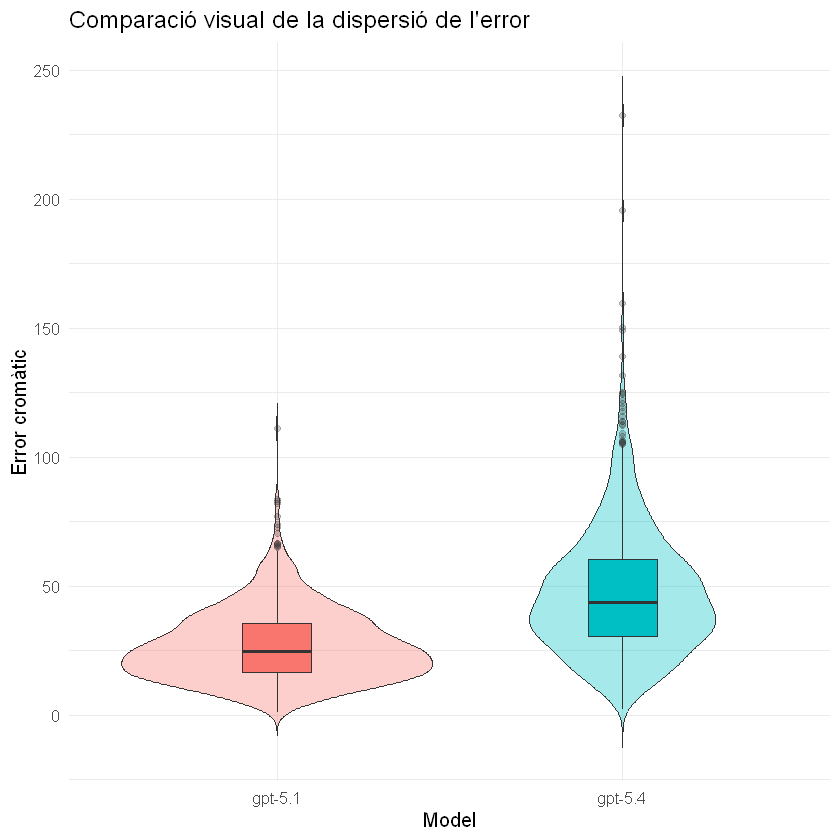

In [27]:
# Comparació descriptiva de desviacions típiques i variàncies.
variabilitat <- dades_models %>%
  group_by(model) %>%
  summarise(
    n = n(),
    desviacio_tipica = sd(error_cromatic, na.rm = TRUE),
    variancia = var(error_cromatic, na.rm = TRUE),
    iqr = IQR(error_cromatic, na.rm = TRUE),
    rang = max(error_cromatic, na.rm = TRUE) - min(error_cromatic, na.rm = TRUE),
    .groups = "drop"
  )

knitr::kable(variabilitat, digits = 4, caption = "Comparació descriptiva de variabilitat")

ggplot(dades_models, aes(x = model, y = error_cromatic, fill = model)) +
  geom_violin(alpha = 0.35, trim = FALSE) +
  geom_boxplot(width = 0.2, outlier.alpha = 0.25) +
  labs(
    title = "Comparació visual de la dispersió de l'error",
    x = "Model",
    y = "Error cromàtic"
  ) +
  guides(fill = "none")


**Interpretació aplicada.** Aquesta comparació és descriptiva. El model amb menor desviació típica, menor variància i una caixa més compacta al gràfic es pot considerar més estable en aquest dataset.


### 3.4.6. Models estadístics

#### A) Model per diferència aparellada


In [28]:
# Model de la diferència aparellada: lm(D ~ 1).
model_D <- lm(D ~ 1, data = dades_aparellades)
resum_model_D <- broom::tidy(model_D, conf.int = TRUE)
glance_model_D <- broom::glance(model_D)

knitr::kable(resum_model_D, digits = 6, caption = "Model lm(D ~ 1)")
knitr::kable(glance_model_D %>% select(sigma, statistic, p.value, df, df.residual), digits = 6, caption = "Indicadors del model de diferència")




Table: Model lm(D ~ 1)

|term        |  estimate| std.error| statistic| p.value|  conf.low| conf.high|
|:-----------|---------:|---------:|---------:|-------:|---------:|---------:|
|(Intercept) | -20.65811|  0.860696| -24.00164|       0| -22.34709| -18.96914|



Table: Indicadors del model de diferència

|   sigma| statistic| p.value| df| df.residual|
|-------:|---------:|-------:|--:|-----------:|
| 27.2176|        NA|      NA| NA|         999|

**Interpretació aplicada.** L'intercept del model `lm(D ~ 1)` és la diferència mitjana entre els dos models. Coincideix amb l'estimació del t-test aparellat perquè tots dos contrasten si la diferència mitjana és zero.


#### B) Model lineal simple


In [29]:
# Models lineals simples: error ~ chroma, un per model.
models_simples <- dades_models %>%
  group_by(model) %>%
  nest() %>%
  mutate(
    ajust = map(data, ~ lm(error_cromatic ~ chroma, data = .x)),
    coeficients = map(ajust, ~ broom::tidy(.x, conf.int = TRUE)),
    indicadors = map(ajust, broom::glance)
  )

taula_models_simples <- models_simples %>%
  select(model, coeficients) %>%
  unnest(coeficients)

indicadors_models_simples <- models_simples %>%
  select(model, indicadors) %>%
  unnest(indicadors) %>%
  select(model, r.squared, adj.r.squared, sigma, p.value, df.residual)

knitr::kable(taula_models_simples, digits = 6, caption = "Coeficients dels models error ~ chroma")
knitr::kable(indicadors_models_simples, digits = 6, caption = "Indicadors dels models simples")




Table: Coeficients dels models error ~ chroma

|model   |term        |  estimate| std.error| statistic|  p.value|  conf.low| conf.high|
|:-------|:-----------|---------:|---------:|---------:|--------:|---------:|---------:|
|gpt-5.1 |(Intercept) | 19.816926|  0.995541| 19.905695| 0.000000|  17.86333| 21.770519|
|gpt-5.1 |chroma      | 16.527630|  2.080636|  7.943546| 0.000000|  12.44471| 20.610554|
|gpt-5.4 |(Intercept) | 49.490361|  1.844519| 26.831036| 0.000000|  45.87078| 53.109942|
|gpt-5.4 |chroma      | -4.334679|  3.854965| -1.124441| 0.261097| -11.89945|  3.230087|



Table: Indicadors dels models simples

|model   | r.squared| adj.r.squared|    sigma|  p.value| df.residual|
|:-------|---------:|-------------:|--------:|--------:|-----------:|
|gpt-5.1 |  0.059467|      0.058524| 13.51644| 0.000000|         998|
|gpt-5.4 |  0.001265|      0.000265| 25.04302| 0.261097|         998|

`geom_smooth()` using formula = 'y ~ x'


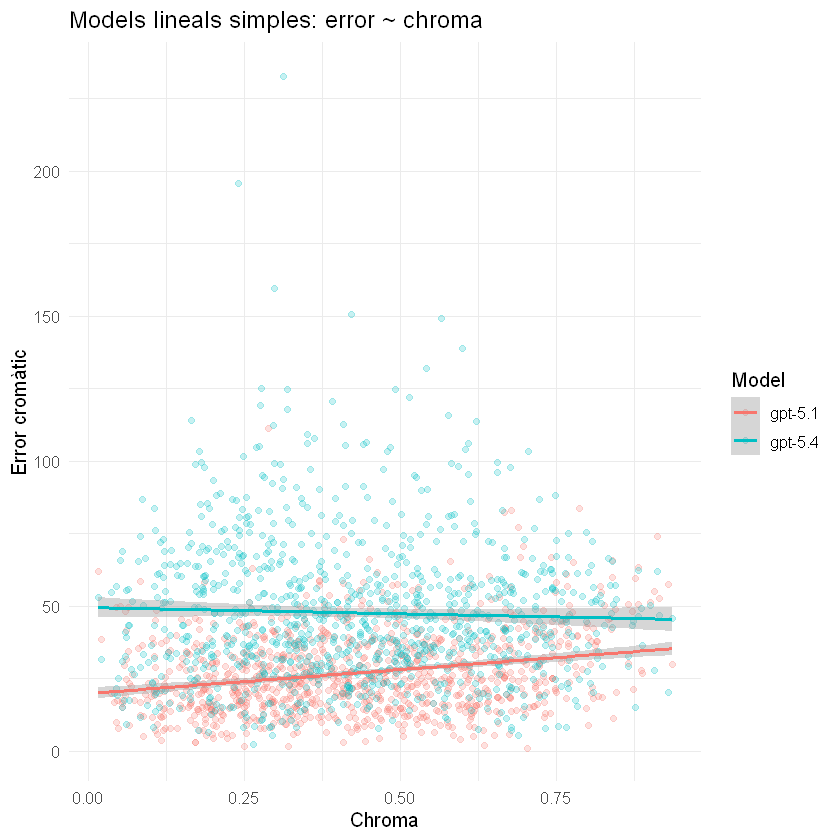

In [30]:
# Gràfic amb rectes de regressió dels models simples.
ggplot(dades_models, aes(x = chroma, y = error_cromatic, color = model)) +
  geom_point(alpha = 0.22) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "Models lineals simples: error ~ chroma",
    x = "Chroma",
    y = "Error cromàtic",
    color = "Model"
  )


**Interpretació aplicada.** La pendent del `chroma` indica com canvia l'error quan augmenta la saturació del color. L'R² mostra quina part de la variabilitat de l'error queda explicada només pel `chroma`.


#### C) Model lineal múltiple


In [31]:
# Model lineal múltiple: error ~ chroma + model.
model_multiple <- lm(error_cromatic ~ chroma + model, data = dades_models)
coef_model_multiple <- broom::tidy(model_multiple, conf.int = TRUE)
indicadors_model_multiple <- broom::glance(model_multiple) %>%
  select(r.squared, adj.r.squared, sigma, statistic, p.value, df.residual)

knitr::kable(coef_model_multiple, digits = 6, caption = "Coeficients del model múltiple")
knitr::kable(indicadors_model_multiple, digits = 6, caption = "Indicadors del model múltiple")




Table: Coeficients del model múltiple

|term         |  estimate| std.error| statistic|  p.value|  conf.low| conf.high|
|:------------|---------:|---------:|---------:|--------:|---------:|---------:|
|(Intercept)  | 24.324586|  1.146701|  21.21268| 0.000000| 22.075731|  26.57344|
|chroma       |  6.096476|  2.202166|   2.76840| 0.005685|  1.777693|  10.41526|
|modelgpt-5.4 | 20.658115|  0.904787|  22.83202| 0.000000| 18.883690|  22.43254|



Table: Indicadors del model múltiple

| r.squared| adj.r.squared|    sigma| statistic| p.value| df.residual|
|---------:|-------------:|--------:|---------:|-------:|-----------:|
|  0.209411|      0.208619| 20.23165|  264.4827|       0|        1997|

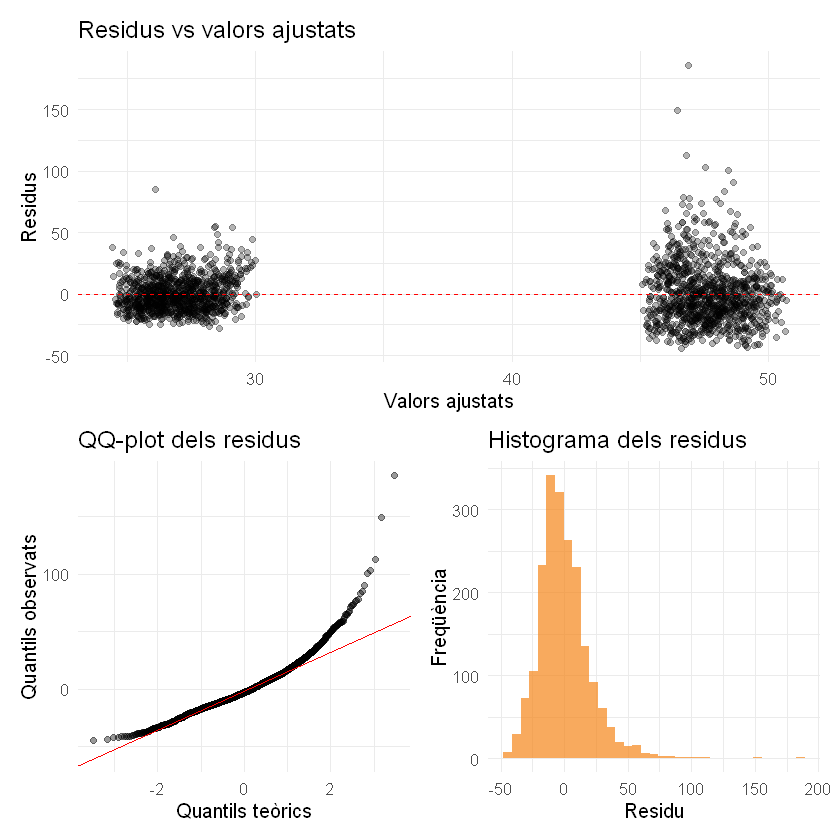

In [32]:
# Diagnòstic visual bàsic del model múltiple.
diagnostic_multiple <- tibble(
  ajustats = fitted(model_multiple),
  residus = residuals(model_multiple)
)

graf_residus_ajustats <- ggplot(diagnostic_multiple, aes(x = ajustats, y = residus)) +
  geom_point(alpha = 0.3) +
  geom_hline(yintercept = 0, color = "red", linetype = "dashed") +
  labs(
    title = "Residus vs valors ajustats",
    x = "Valors ajustats",
    y = "Residus"
  )

graf_qq_residus <- ggplot(diagnostic_multiple, aes(sample = residus)) +
  stat_qq(alpha = 0.4) +
  stat_qq_line(color = "red") +
  labs(
    title = "QQ-plot dels residus",
    x = "Quantils teòrics",
    y = "Quantils observats"
  )

graf_hist_residus <- ggplot(diagnostic_multiple, aes(x = residus)) +
  geom_histogram(bins = 35, fill = "#F58518", alpha = 0.7) +
  labs(
    title = "Histograma dels residus",
    x = "Residu",
    y = "Freqüència"
  )

graf_residus_ajustats / (graf_qq_residus + graf_hist_residus)


**Interpretació aplicada.** El coeficient del model indica si **gpt-5.4** manté una diferència d'error respecte de **gpt-5.1** després de controlar pel `chroma`. Si aquest coeficient és significatiu, el model continua sent rellevant més enllà de la saturació del color.


## 4. Resultats

### 4.1. Descripció de les dades


In [33]:
# Resum final de dades utilitzades en l'estudi.
resum_resultats_dades <- tibble(
  indicador = c(
    "Observacions filtrades",
    "Parelles vàlides",
    "Valors perduts en error",
    "Valors perduts en chroma",
    "Mínim error",
    "Màxim error",
    "Mínim chroma",
    "Màxim chroma"
  ),
  valor = c(
    nrow(dades_models),
    nrow(dades_aparellades),
    sum(is.na(dades_models$error_cromatic)),
    sum(is.na(dades_models$chroma)),
    min(dades_models$error_cromatic, na.rm = TRUE),
    max(dades_models$error_cromatic, na.rm = TRUE),
    min(dades_models$chroma, na.rm = TRUE),
    max(dades_models$chroma, na.rm = TRUE)
  )
)

knitr::kable(resum_resultats_dades, digits = 4, caption = "Dades finals utilitzades")




Table: Dades finals utilitzades

|indicador                |     valor|
|:------------------------|---------:|
|Observacions filtrades   | 2000.0000|
|Parelles vàlides         | 1000.0000|
|Valors perduts en error  |    0.0000|
|Valors perduts en chroma |    0.0000|
|Mínim error              |    1.0000|
|Màxim error              |  232.5812|
|Mínim chroma             |    0.0165|
|Màxim chroma             |    0.9363|

### 4.2. Anàlisi descriptiu

Les taules i gràfics de la secció 3.4.1 mostren la distribució de l'error per model, la concentració de respostes i els percentatges d'encert segons llindars. En aquest estudi, la comparació descriptiva és el primer pas per valorar quin model té menor error i quin és més estable.


In [34]:
# Taula compacta per a resultats descriptius.
taula_resultats_descriptius <- descriptiva_error %>%
  select(model, n, mitjana, mediana, desviacio_tipica, variancia, iqr, minim, maxim)

knitr::kable(taula_resultats_descriptius, digits = 4, caption = "Resultats descriptius principals")




Table: Resultats descriptius principals

|model   |    n| mitjana| mediana| desviacio_tipica| variancia|     iqr|  minim|    maxim|
|:-------|----:|-------:|-------:|----------------:|---------:|-------:|------:|--------:|
|gpt-5.1 | 1000| 26.9591| 24.8395|          13.9302|  194.0509| 18.9526| 1.0000| 111.2025|
|gpt-5.4 | 1000| 47.6172| 43.7664|          25.0463|  627.3188| 29.7171| 2.2361| 232.5812|

### 4.3. Resultats dels contrastos


In [35]:
knitr::kable(resum_test_t, digits = 6, caption = "Resultats del contrast t aparellat")

diferencia_mitjana <- resum_test_t$diferencia_mitjana
model_millor <- ifelse(diferencia_mitjana < 0, model_a, model_b)

tibble(
  interpretacio = paste(
    "La diferència mitjana D és", round(diferencia_mitjana, 4),
    ". El model amb menor error mitjà és", model_millor,
    "segons el signe de D."
  )
) %>%
  knitr::kable(caption = "Interpretació automàtica del signe de la diferència")




Table: Resultats del contrast t aparellat

| diferencia_mitjana|  conf_low| conf_high| estadistic_t| graus_llibertat| p_value|
|------------------:|---------:|---------:|------------:|---------------:|-------:|
|          -20.65811| -22.34709| -18.96914|    -24.00164|             999|       0|



Table: Interpretació automàtica del signe de la diferència

|interpretacio                                                                                         |
|:-----------------------------------------------------------------------------------------------------|
|La diferència mitjana D és -20.6581 . El model amb menor error mitjà és gpt-5.1 segons el signe de D. |

### 4.4. Models estadístics

Els models estadístics ajustats són:

- `lm(D ~ 1)`, equivalent a estimar la diferència mitjana aparellada.
- `error_cromatic ~ chroma`, ajustat separadament per model.
- `error_cromatic ~ chroma + model`, per valorar l'efecte del model controlant pel `chroma`.


In [36]:
knitr::kable(resum_model_D, digits = 6, caption = "Resultats de lm(D ~ 1)")
knitr::kable(taula_models_simples, digits = 6, caption = "Regressions simples per model")
knitr::kable(coef_model_multiple, digits = 6, caption = "Regressió múltiple")




Table: Resultats de lm(D ~ 1)

|term        |  estimate| std.error| statistic| p.value|  conf.low| conf.high|
|:-----------|---------:|---------:|---------:|-------:|---------:|---------:|
|(Intercept) | -20.65811|  0.860696| -24.00164|       0| -22.34709| -18.96914|



Table: Regressions simples per model

|model   |term        |  estimate| std.error| statistic|  p.value|  conf.low| conf.high|
|:-------|:-----------|---------:|---------:|---------:|--------:|---------:|---------:|
|gpt-5.1 |(Intercept) | 19.816926|  0.995541| 19.905695| 0.000000|  17.86333| 21.770519|
|gpt-5.1 |chroma      | 16.527630|  2.080636|  7.943546| 0.000000|  12.44471| 20.610554|
|gpt-5.4 |(Intercept) | 49.490361|  1.844519| 26.831036| 0.000000|  45.87078| 53.109942|
|gpt-5.4 |chroma      | -4.334679|  3.854965| -1.124441| 0.261097| -11.89945|  3.230087|



Table: Regressió múltiple

|term         |  estimate| std.error| statistic|  p.value|  conf.low| conf.high|
|:------------|---------:|---------:|---------:|--------:|---------:|---------:|
|(Intercept)  | 24.324586|  1.146701|  21.21268| 0.000000| 22.075731|  26.57344|
|chroma       |  6.096476|  2.202166|   2.76840| 0.005685|  1.777693|  10.41526|
|modelgpt-5.4 | 20.658115|  0.904787|  22.83202| 0.000000| 18.883690|  22.43254|

### 4.5. Transformacions de variables

Es valora una transformació logarítmica amb `log1p(error)` perquè l'error és positiu i pot presentar asimetria. Aquesta transformació només es considera com a diagnòstic; la comparació principal es manté en l'escala original de l'error cromàtic.




Table: Comparació descriptiva entre escala original i logarítmica

|escala       | mitjana_diferencia| sd_diferencia|
|:------------|------------------:|-------------:|
|Original     |         -20.658115|     27.217602|
|log1p(error) |          -0.551255|      0.728476|

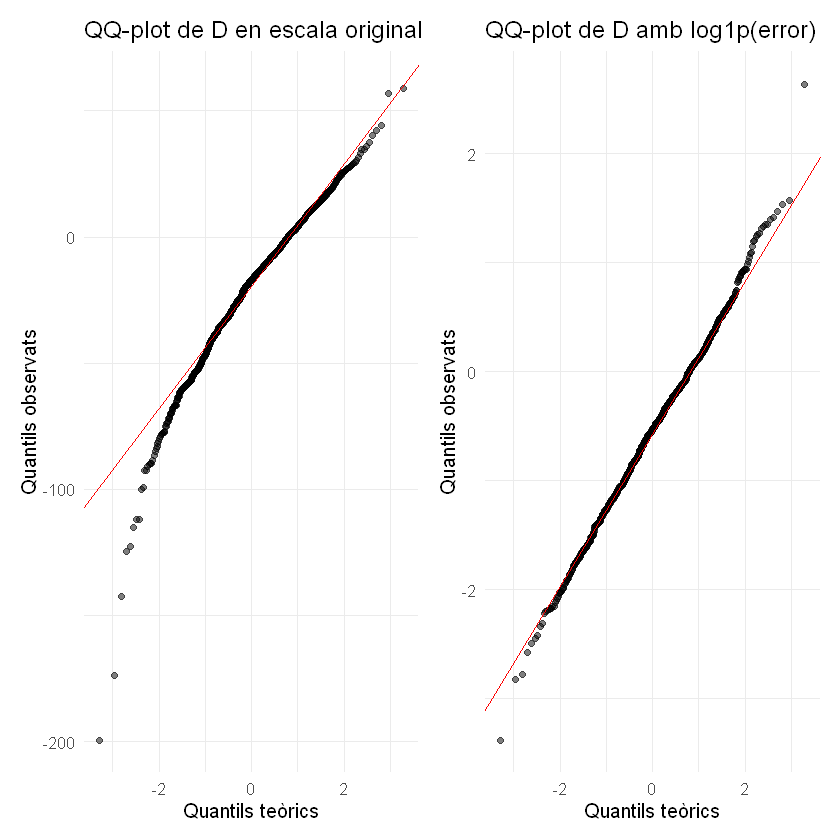

In [37]:
# Valoració gràfica de la transformació logarítmica.
dades_log <- dades_aparellades %>%
  mutate(
    log_error_5_1 = log1p(error_5_1),
    log_error_5_4 = log1p(error_5_4),
    D_log = log_error_5_1 - log_error_5_4
  )

graf_qq_D_original <- ggplot(dades_log, aes(sample = D)) +
  stat_qq(alpha = 0.5) +
  stat_qq_line(color = "red") +
  labs(title = "QQ-plot de D en escala original", x = "Quantils teòrics", y = "Quantils observats")

graf_qq_D_log <- ggplot(dades_log, aes(sample = D_log)) +
  stat_qq(alpha = 0.5) +
  stat_qq_line(color = "red") +
  labs(title = "QQ-plot de D amb log1p(error)", x = "Quantils teòrics", y = "Quantils observats")

resum_log <- tibble(
  escala = c("Original", "log1p(error)"),
  mitjana_diferencia = c(mean(dades_log$D), mean(dades_log$D_log)),
  sd_diferencia = c(sd(dades_log$D), sd(dades_log$D_log))
)

graf_qq_D_original + graf_qq_D_log
knitr::kable(resum_log, digits = 6, caption = "Comparació descriptiva entre escala original i logarítmica")


**Interpretació aplicada.** Si el QQ-plot logarítmic és més alineat que l'original, la transformació pot ajudar en la normalitat visual. Tot i això, la interpretació principal és més directa en unitats d'error cromàtic original.


### 4.6. Anàlisi gràfic de les premisses

Els QQ-plots, el Bland-Altman i els gràfics de residus indiquen si les premisses són prou raonables per interpretar els resultats. En aquest dataset, la decisió principal depèn sobretot de la distribució de les diferències aparellades i de si el patró del Bland-Altman suggereix diferències additives o dependents del nivell d'error.


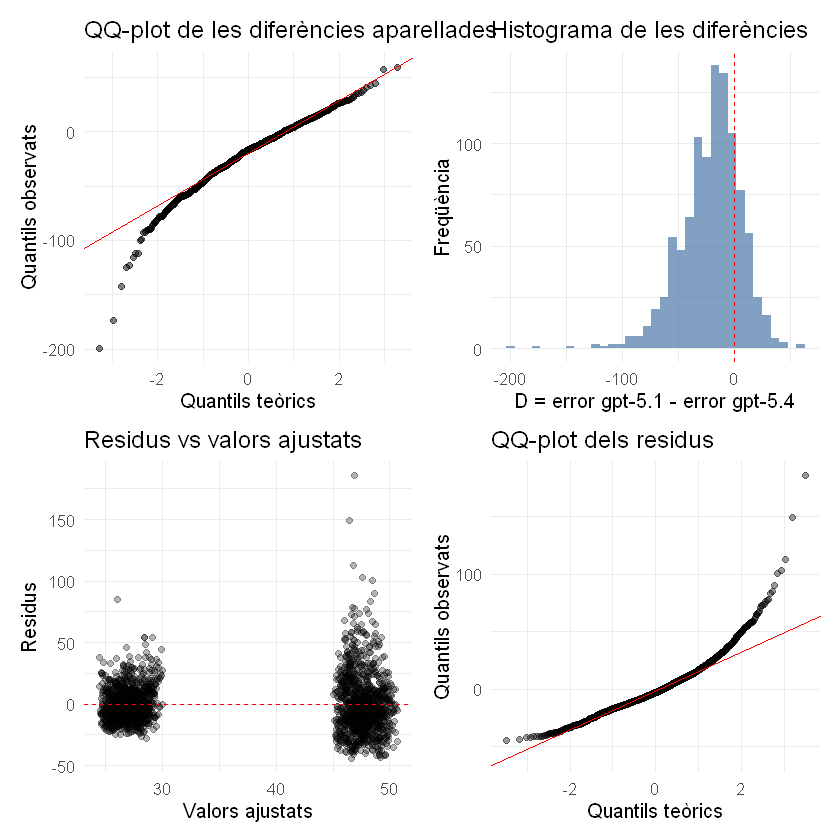

In [38]:
# Resum gràfic final de premisses.
(graf_qq_D + graf_hist_D) / (graf_residus_ajustats + graf_qq_residus)


## 5. Discussió

### 5.1. Interpretació dels resultats

El model amb menor error mitjà es determina a partir de la diferència aparellada \(D\). Si \(D < 0\), **gpt-5.1** té menor error mitjà; si \(D > 0\), **gpt-5.4** té menor error mitjà. La magnitud de la diferència s'ha d'interpretar en unitats d'error cromàtic.

La relació amb `chroma` s'avalua amb correlacions, buckets de chroma i models lineals simples. Si les pendents són positives, els colors amb més chroma tendeixen a presentar més error.

### 5.2. Relació amb les hipòtesis

La hipòtesi principal contrasta si la diferència mitjana entre models és zero. El p-value del t-test aparellat indica si la diferència observada és compatible amb una diferència mitjana nul·la en aquest disseny aparellat.

### 5.3. Limitacions de l'estudi

- La informació sobre prompt, mida, format i compressió no apareix al CSV: **PENDENT**.
- No es pot verificar des del CSV si hi ha aleatorietat estricta en la selecció dels colors.
- El prompt podria introduir biaixos no observats.
- La mida mostral és gran per a la comparació, però limitada al conjunt d'imatges disponible.
- Les premisses s'han validat principalment de forma gràfica.
- L'error depèn de l'espai de color utilitzat i aquí s'analitza l'error ja disponible al CSV.

### 5.4. Implicacions i conseqüències

Si un model presenta menor error i menor variabilitat, és més adequat per a tasques on cal estimar colors amb precisió. El paper del `chroma` és important perquè pot indicar que els colors més saturats requereixen més control experimental o una estratègia de predicció més precisa.


## 6. Conclusions

Les conclusions finals s'obtenen directament de les taules del notebook:

- El model amb menor error mitjà és el que queda indicat pel signe de \(D\).
- La significació estadística depèn del p-value del t-test aparellat.
- El `chroma` pot tenir relació amb l'error si les correlacions i pendents són diferents de zero.
- Els models lineals són adequats com a aproximació descriptiva i inferencial bàsica, sempre interpretant els diagnòstics gràfics.


In [39]:
# Conclusió automàtica breu basada en els resultats calculats.
conclusio_automatica <- tibble(
  element = c(
    "Model amb menor error mitjà",
    "Diferència mitjana D",
    "IC 95% inferior",
    "IC 95% superior",
    "p-value",
    "Interpretació de significació"
  ),
  resultat = c(
    model_millor,
    round(resum_test_t$diferencia_mitjana, 4),
    round(resum_test_t$conf_low, 4),
    round(resum_test_t$conf_high, 4),
    format.pval(resum_test_t$p_value, digits = 4, eps = 0.0001),
    ifelse(resum_test_t$p_value < 0.05, "Hi ha evidència de diferència mitjana", "No hi ha evidència suficient de diferència mitjana")
  )
)

knitr::kable(conclusio_automatica, caption = "Conclusió automàtica del contrast principal")




Table: Conclusió automàtica del contrast principal

|element                       |resultat                              |
|:-----------------------------|:-------------------------------------|
|Model amb menor error mitjà   |gpt-5.1                               |
|Diferència mitjana D          |-20.6581                              |
|IC 95% inferior               |-22.3471                              |
|IC 95% superior               |-18.9691                              |
|p-value                       |< 0.0001                              |
|Interpretació de significació |Hi ha evidència de diferència mitjana |

## 7. Recomanacions per a futurs estudis

- Ampliar la mostra amb nous colors i condicions visuals.
- Registrar i controlar millor els prompts utilitzats.
- Incloure variables de mida, format i compressió de les imatges.
- Estudiar altres variables de color a més del `chroma`.
- Validar els resultats amb altres datasets.


## 8. Referències

- R Core Team. Documentació de la funció `t.test()`.
- R Core Team. Documentació de la funció `lm()`.
- Wickham et al. Llibreries `tidyverse`, `ggplot2`, `dplyr` i `tidyr`.
- Robinson, Hayes i Couch. Llibreria `broom`.
- Xie. Llibreria `knitr`.
- Pedersen. Llibreria `patchwork`.


## 9. Annexos

### 9.1. Codi en R

Tot el codi complet de l'anàlisi està inclòs dins de les cel·les anteriors d'aquest notebook. No s'ha utilitzat cap script extern ni `analysis_functions.R`.


In [40]:
# Informació de sessió per garantir reproductibilitat.
sessionInfo()


R version 4.5.3 (2026-03-11 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=Spanish_Spain.utf8  LC_CTYPE=Spanish_Spain.utf8   
[3] LC_MONETARY=Spanish_Spain.utf8 LC_NUMERIC=C                  
[5] LC_TIME=Spanish_Spain.utf8    

time zone: Europe/Madrid
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] patchwork_1.3.2 knitr_1.51      broom_1.0.12    lubridate_1.9.5
 [5] forcats_1.0.1   stringr_1.6.0   dplyr_1.2.1     purrr_1.2.2    
 [9] readr_2.2.0     tidyr_1.3.2     tibble_3.3.1    ggplot2_4.0.3  
[13] tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] generics_0.1.4     lattice_0.22-9     stringi_1.8.7      hms_1.1.4         
 [5] digest_0.6.39      magrittr_2.0.5     evaluate_1.0.5     grid_4.5.3        
 [9] timechange_0.4.0   RColorBrewer_1.1-3 pbdZMQ_0.3-

### 9.2. Dades utilitzades


In [41]:
# Resum final de les dades utilitzades i criteris de filtratge.
annex_dades <- tibble(
  camp = c(
    "Ruta utilitzada",
    "Models analitzats",
    "Variable resposta Y",
    "Variable explicativa X",
    "Covariable Z",
    "Criteri de filtratge",
    "Nombre final d'observacions",
    "Nombre de parelles"
  ),
  valor = c(
    ruta_csv,
    paste(model_a, "i", model_b),
    "error_cromatic",
    "model",
    "chroma",
    "model %in% c('gpt-5.1', 'gpt-5.4') i status == 'ok'",
    nrow(dades_models),
    nrow(dades_aparellades)
  )
)

knitr::kable(annex_dades, caption = "Dades utilitzades a l'estudi")




Table: Dades utilitzades a l'estudi

|camp                        |valor                                                                                                                                    |
|:---------------------------|:----------------------------------------------------------------------------------------------------------------------------------------|
|Ruta utilitzada             |C:/Users/AdriàSebastià/Documents/dev/color-llm-benchmark/recollida-dades/experiments/soroll/results/sample_colors_tots_models_actual.csv |
|Models analitzats           |gpt-5.1 i gpt-5.4                                                                                                                        |
|Variable resposta Y         |error_cromatic                                                                                                                           |
|Variable explicativa X      |model                                                                                 